<a href="https://colab.research.google.com/github/biswal-prem-5677/Coding-Journey/blob/main/ai/03_deep_learning/architectures/cnn/experiment_cnn_mnist_progressive_improvement_pytorch_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# ============================================
# LEVEL 1: BASIC CNN (MNIST)
# ============================================

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

# -------------------------------
# 1. Load Data
# -------------------------------
transform = transforms.ToTensor()

train_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

# -------------------------------
# 2. CNN Model
# -------------------------------
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()

        # First filter layer
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3)

        # Second filter layer
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3)

        # Fully connected
        self.fc = nn.Linear(32 * 24 * 24, 10)

    def forward(self, x):

        # Apply filters
        x = torch.relu(self.conv1(x))  # edge detection

        x = torch.relu(self.conv2(x))  # shape detection

        # Flatten image
        x = x.view(x.size(0), -1)

        # Final classification
        return self.fc(x)


model = SimpleCNN()

# -------------------------------
# 3. Training
# -------------------------------
optimizer = optim.Adam(model.parameters(), lr=0.001)
loss_fn = nn.CrossEntropyLoss()

loss_history_cnn = []

for epoch in range(3):

    total_loss = 0

    for images, labels in train_loader:

        optimizer.zero_grad()

        outputs = model(images)

        loss = loss_fn(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    loss_history_cnn.append(avg_loss)

    print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}")

100%|██████████| 9.91M/9.91M [00:00<00:00, 66.2MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.64MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.6MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.96MB/s]


Epoch 1, Loss: 0.1698
Epoch 2, Loss: 0.0563
Epoch 3, Loss: 0.0379


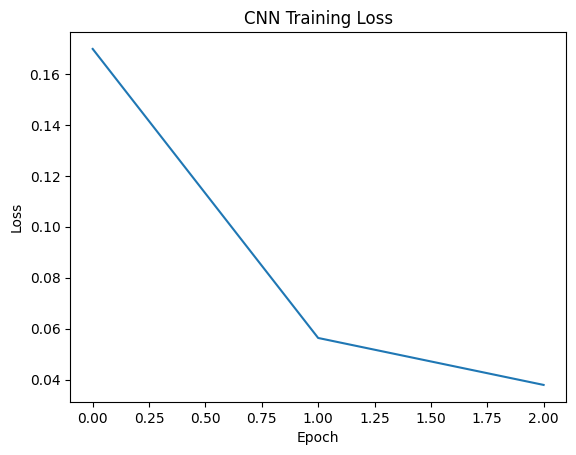

In [4]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(loss_history_cnn)
plt.title("CNN Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

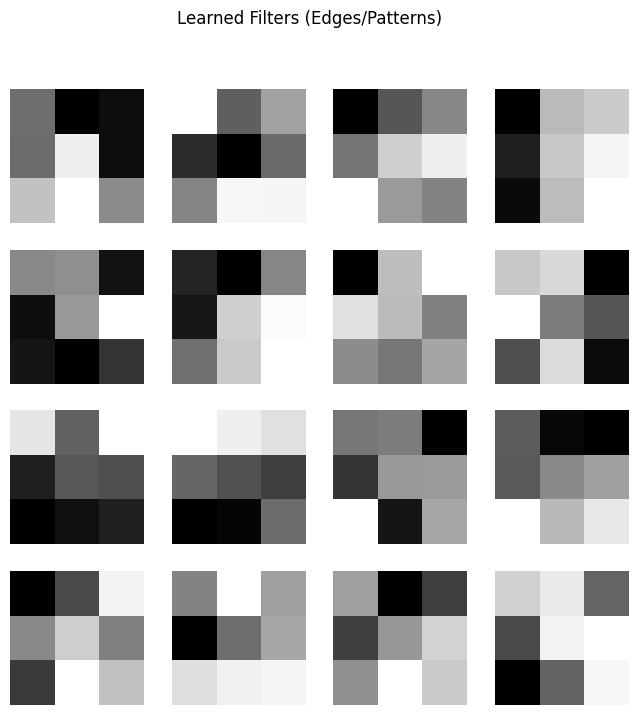

In [5]:
filters = model.conv1.weight.data.clone()

plt.figure(figsize=(8,8))

for i in range(16):
    plt.subplot(4,4,i+1)
    plt.imshow(filters[i][0], cmap='gray')
    plt.axis('off')

plt.suptitle("Learned Filters (Edges/Patterns)")
plt.show()

In [6]:
# ============================================
# LEVEL 2: CNN WITH POOLING (REALISTIC)
# ============================================

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

# -------------------------------
# 1. Data (same MNIST)
# -------------------------------
transform = transforms.ToTensor()

train_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

# -------------------------------
# 2. Improved CNN Model
# -------------------------------
class BetterCNN(nn.Module):
    def __init__(self):
        super().__init__()

        # Block 1
        self.conv1 = nn.Conv2d(1, 16, 3)
        self.pool = nn.MaxPool2d(2)

        # Block 2
        self.conv2 = nn.Conv2d(16, 32, 3)

        # Fully connected
        self.fc = nn.Linear(32 * 5 * 5, 10)

    def forward(self, x):

        # Block 1
        x = torch.relu(self.conv1(x))
        x = self.pool(x)

        # Block 2
        x = torch.relu(self.conv2(x))
        x = self.pool(x)

        # Flatten
        x = x.view(x.size(0), -1)

        return self.fc(x)


model = BetterCNN()

# -------------------------------
# 3. Training
# -------------------------------
optimizer = optim.Adam(model.parameters(), lr=0.001)
loss_fn = nn.CrossEntropyLoss()

loss_history_cnn2 = []

for epoch in range(3):

    total_loss = 0

    for images, labels in train_loader:

        optimizer.zero_grad()

        outputs = model(images)

        loss = loss_fn(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    loss_history_cnn2.append(avg_loss)

    print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}")

Epoch 1, Loss: 0.2715
Epoch 2, Loss: 0.0810
Epoch 3, Loss: 0.0608


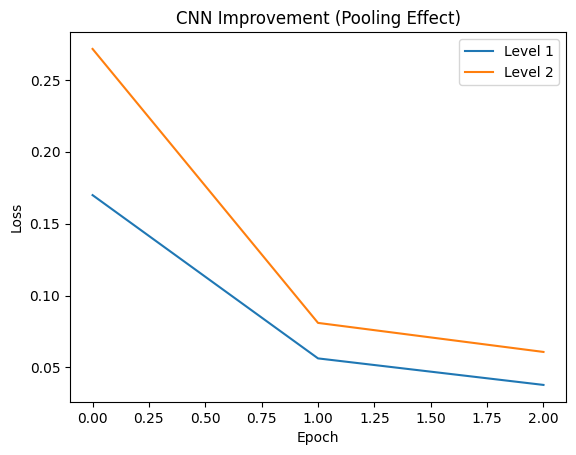

In [7]:
import matplotlib.pyplot as plt

plt.figure()

plt.plot(loss_history_cnn, label="Level 1")
plt.plot(loss_history_cnn2, label="Level 2")

plt.title("CNN Improvement (Pooling Effect)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

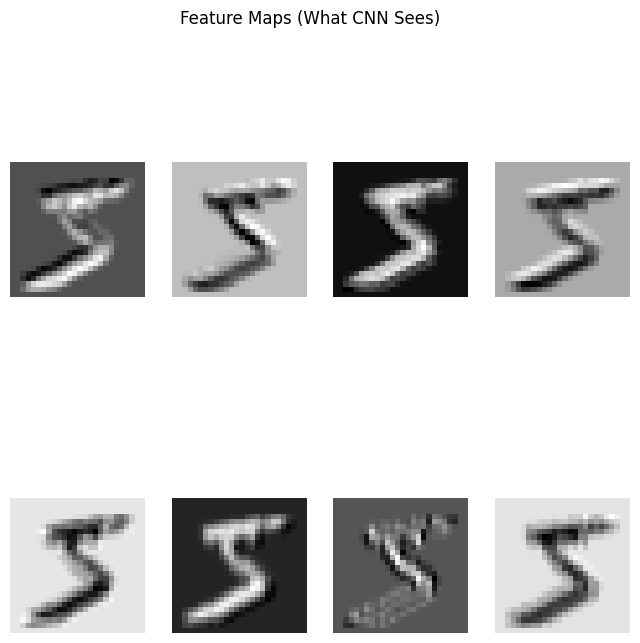

In [8]:
# Take one image
sample_img, _ = train_dataset[0]
sample_img = sample_img.unsqueeze(0)

# Pass through first conv layer
with torch.no_grad():
    feature_maps = model.conv1(sample_img)

plt.figure(figsize=(8,8))

for i in range(8):
    plt.subplot(2,4,i+1)
    plt.imshow(feature_maps[0][i], cmap='gray')
    plt.axis('off')

plt.suptitle("Feature Maps (What CNN Sees)")
plt.show()

In [9]:
# ============================================
# LEVEL 3: CNN WITH ACCURACY (REAL MODEL)
# ============================================

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

# -------------------------------
# 1. Data (Train + Test)
# -------------------------------
transform = transforms.ToTensor()

train_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)

# -------------------------------
# 2. Model (same as Level 2)
# -------------------------------
class BetterCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, 3)
        self.pool = nn.MaxPool2d(2)
        self.conv2 = nn.Conv2d(16, 32, 3)
        self.fc = nn.Linear(32 * 5 * 5, 10)

    def forward(self, x):
        x = torch.relu(self.conv1(x))
        x = self.pool(x)
        x = torch.relu(self.conv2(x))
        x = self.pool(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)

model = BetterCNN()

# -------------------------------
# 3. Training
# -------------------------------
optimizer = optim.Adam(model.parameters(), lr=0.001)
loss_fn = nn.CrossEntropyLoss()

for epoch in range(3):

    model.train()
    for images, labels in train_loader:
        optimizer.zero_grad()

        outputs = model(images)
        loss = loss_fn(outputs, labels)

        loss.backward()
        optimizer.step()

    print(f"Epoch {epoch+1} done")

# -------------------------------
# 4. Evaluation (IMPORTANT)
# -------------------------------
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        correct += (predicted == labels).sum().item()
        total += labels.size(0)

accuracy = correct / total

print(f"Test Accuracy: {accuracy:.4f}")

Epoch 1 done
Epoch 2 done
Epoch 3 done
Test Accuracy: 0.9830


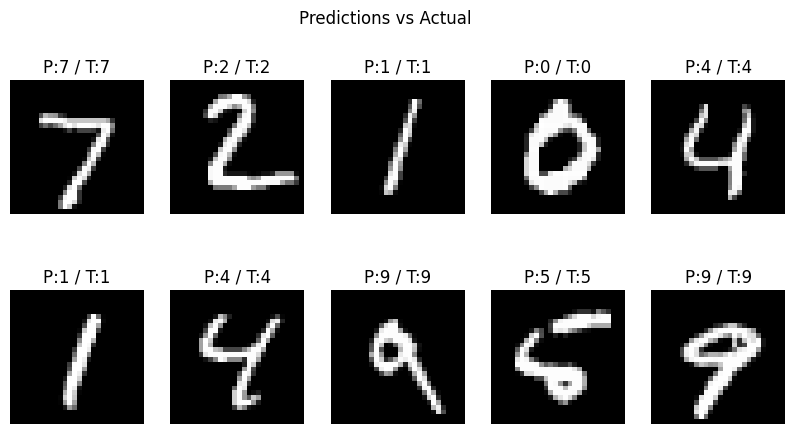

In [10]:
import matplotlib.pyplot as plt

# Take batch
images, labels = next(iter(test_loader))

outputs = model(images)
_, preds = torch.max(outputs, 1)

plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(images[i][0], cmap='gray')
    plt.title(f"P:{preds[i].item()} / T:{labels[i].item()}")
    plt.axis('off')

plt.suptitle("Predictions vs Actual")
plt.show()

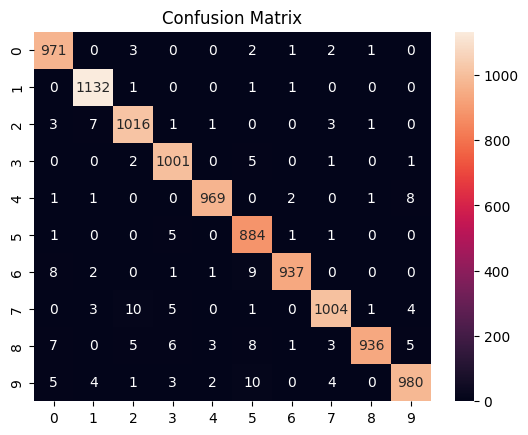

In [11]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

In [12]:
# ============================================
# LEVEL 4: PRODUCTION CNN SYSTEM
# ============================================

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

# -------------------------------
# 1. Device (GPU if available)
# -------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# -------------------------------
# 2. Data
# -------------------------------
transform = transforms.ToTensor()

train_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader  = torch.utils.data.DataLoader(test_dataset, batch_size=128, shuffle=False)

# -------------------------------
# 3. Model (same architecture)
# -------------------------------
class BetterCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, 3)
        self.pool = nn.MaxPool2d(2)
        self.conv2 = nn.Conv2d(16, 32, 3)
        self.fc = nn.Linear(32 * 5 * 5, 10)

    def forward(self, x):
        x = torch.relu(self.conv1(x))
        x = self.pool(x)
        x = torch.relu(self.conv2(x))
        x = self.pool(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)

model = BetterCNN().to(device)

# -------------------------------
# 4. Training
# -------------------------------
optimizer = optim.Adam(model.parameters(), lr=0.001)
loss_fn = nn.CrossEntropyLoss()

for epoch in range(3):

    model.train()
    total_loss = 0

    for images, labels in train_loader:

        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = loss_fn(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader):.4f}")

Epoch 1, Loss: 0.3760
Epoch 2, Loss: 0.1044
Epoch 3, Loss: 0.0752


In [13]:
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:

        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

print("Final Accuracy:", correct / total)

Final Accuracy: 0.9805


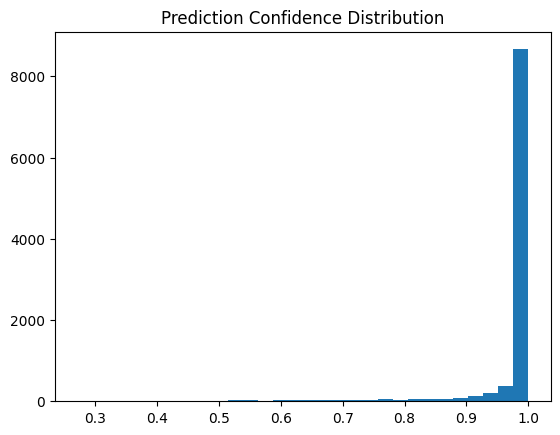

In [14]:
import numpy as np
import matplotlib.pyplot as plt

confidences = []

with torch.no_grad():
    for images, _ in test_loader:
        images = images.to(device)

        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)

        max_conf = probs.max(dim=1)[0]
        confidences.extend(max_conf.cpu().numpy())

plt.figure()
plt.hist(confidences, bins=30)
plt.title("Prediction Confidence Distribution")
plt.show()